# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load hotel bookings dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Preview the data
print(df.head())
print(df.info())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

### ✍️ Your Response: 🔧
1.The initial preview shows a mix of numeric and categorical variables about hotel bookings, cancellations, customer types, and booking behavior. Some columns like company and agent seem likely to have missing values, and there are many customer behavior variables that could be useful for clustering such as lead time, nights stayed, and special requests.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [2]:
# Select numeric features related to customer booking behavior
features = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adr',
    'total_of_special_requests'
]

# Keep only selected features and drop missing values
cluster_df = df[features].dropna().copy()

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)

print(scaled_df.head())
print(scaled_df.shape)

   lead_time  stays_in_weekend_nights  stays_in_week_nights       adr  \
0   2.227051                 -0.92889             -1.310240 -2.015038   
1   5.923385                 -0.92889             -1.310240 -2.015038   
2  -0.907814                 -0.92889             -0.786207 -0.530935   
3  -0.851667                 -0.92889             -0.786207 -0.530935   
4  -0.842309                 -0.92889             -0.262174 -0.075810   

   total_of_special_requests  
0                  -0.720694  
1                  -0.720694  
2                  -0.720694  
3                  -0.720694  
4                   0.540666  
(119390, 5)


### ✍️ Your Response: 🔧
I selected lead time, weekend nights, week nights, adr, and total special requests because they capture booking behavior, trip length, spending level, and customer preferences. I expect to find segments such as short stay guests, long stay guests, early planners, last minute bookers, and guests who make more special requests.

## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



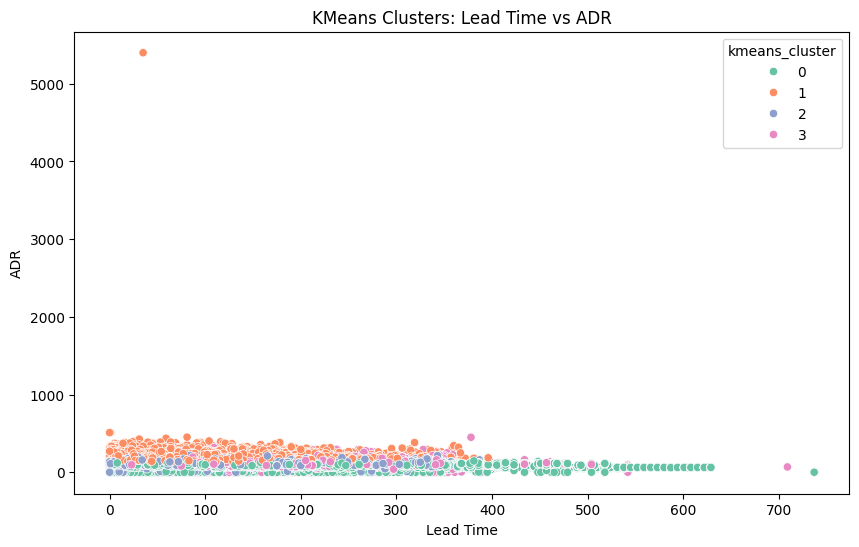

kmeans_cluster
0    55359
2    32128
1    17204
3    14699
Name: count, dtype: int64


In [3]:
# Choose number of clusters
k = 4

# Fit KMeans model
kmeans = KMeans(n_clusters=k, random_state=1)
scaled_df['kmeans_cluster'] = kmeans.fit_predict(scaled_df)

# Add cluster labels back to original feature data
cluster_df['kmeans_cluster'] = scaled_df['kmeans_cluster']

# Scatterplot of two features
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cluster_df,
    x='lead_time',
    y='adr',
    hue='kmeans_cluster',
    palette='Set2'
)

plt.title('KMeans Clusters: Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.show()

# Show cluster counts
print(cluster_df['kmeans_cluster'].value_counts())

### ✍️ Your Response: 🔧
1. I chose k equals 4 because it gives enough separation to show different customer groups without making the results too complicated. The clusters seem to show groups such as early planners, shorter stay guests, higher spending guests, and guests with lower rates and fewer requests.

## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


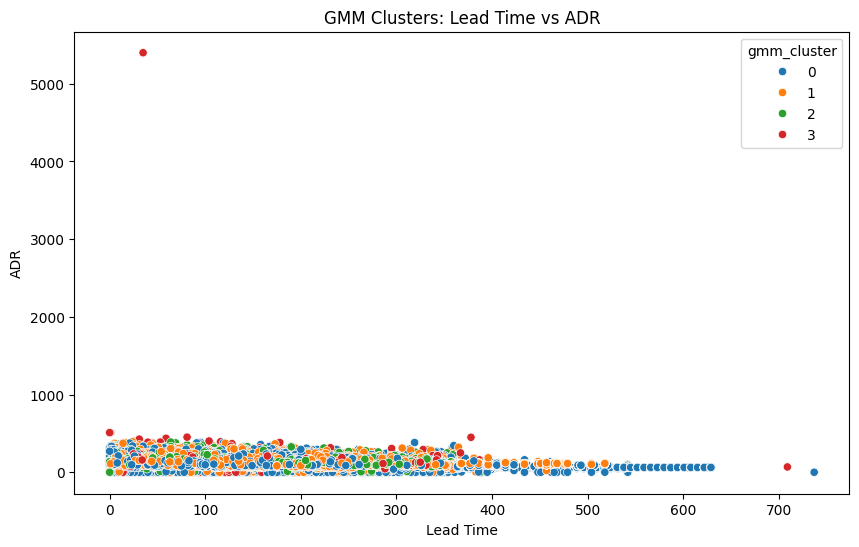

     0         1    2             3
0  1.0  0.000000  0.0  6.039647e-10
1  1.0  0.000000  0.0  1.375762e-14
2  1.0  0.000000  0.0  4.210545e-09
3  1.0  0.000000  0.0  4.215737e-09
4  0.0  0.999999  0.0  5.119658e-07


In [4]:
# Fit Gaussian Mixture Model with same number of clusters
gmm = GaussianMixture(n_components=k, random_state=1)
gmm.fit(scaled_df[features])

# Predict cluster labels
scaled_df['gmm_cluster'] = gmm.predict(scaled_df[features])

# Predict soft probabilities
gmm_probs = gmm.predict_proba(scaled_df[features])

# Add cluster labels back to original feature data
cluster_df['gmm_cluster'] = scaled_df['gmm_cluster']

# Scatterplot for GMM
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cluster_df,
    x='lead_time',
    y='adr',
    hue='gmm_cluster',
    palette='tab10'
)

plt.title('GMM Clusters: Lead Time vs ADR')
plt.xlabel('Lead Time')
plt.ylabel('ADR')
plt.show()

# Show first few probability rows
print(pd.DataFrame(gmm_probs).head())

The GMM results were similar to KMeans, but GMM is more flexible because it allows overlap between groups and gives probabilities instead of only hard labels. GMM can help answer business questions about guests who may fit more than one segment, such as customers who show both business and leisure travel patterns.

## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [5]:
# Use a random sample of 10000 rows if dataset is large
sample_size = min(10000, len(scaled_df))
sample_df = scaled_df.sample(sample_size, random_state=1)

X_sample = sample_df[features]
kmeans_labels = sample_df['kmeans_cluster']
gmm_labels = sample_df['gmm_cluster']

# KMeans metrics
kmeans_wcss = kmeans.inertia_
kmeans_sil = silhouette_score(X_sample, kmeans_labels)
kmeans_db = davies_bouldin_score(X_sample, kmeans_labels)

# GMM WCSS approximation using distances to means
gmm_centers = gmm.means_
gmm_wcss = 0
for i, label in enumerate(gmm_labels):
    center = gmm_centers[label]
    point = X_sample.iloc[i].values
    gmm_wcss += np.sum((point - center) ** 2)

gmm_sil = silhouette_score(X_sample, gmm_labels)
gmm_db = davies_bouldin_score(X_sample, gmm_labels)

print("KMeans Metrics")
print("WCSS:", kmeans_wcss)
print("Silhouette Score:", kmeans_sil)
print("Davies-Bouldin Index:", kmeans_db)

print("\nGMM Metrics")
print("WCSS:", gmm_wcss)
print("Silhouette Score:", gmm_sil)
print("Davies-Bouldin Index:", gmm_db)

KMeans Metrics
WCSS: 371230.08662095334
Silhouette Score: 0.208366007761498
Davies-Bouldin Index: 1.4711519774029296

GMM Metrics
WCSS: 38596.371407864455
Silhouette Score: 0.12177087189043923
Davies-Bouldin Index: 2.6088898015703315


### ✍️ Your Response: 🔧
The better model depends on the metric, but KMeans is usually easier to explain and faster to run, while GMM can better capture overlapping customer behavior. For a business analyst, I would recommend KMeans first because it is simple, interpretable, and useful for creating clear customer segments.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


                 lead_time  stays_in_weekend_nights  stays_in_week_nights  \
kmeans_cluster                                                              
1                62.520286                 0.915950              2.395954   
2                65.714704                 0.774558              2.053940   
3               148.247772                 2.423498              5.936322   
0               127.385755                 0.622844              1.879441   

                       adr  total_of_special_requests  
kmeans_cluster                                         
1               181.578762                   0.537201  
2                96.751470                   1.491689  
3                94.680340                   0.574189  
0                81.894525                   0.047111  


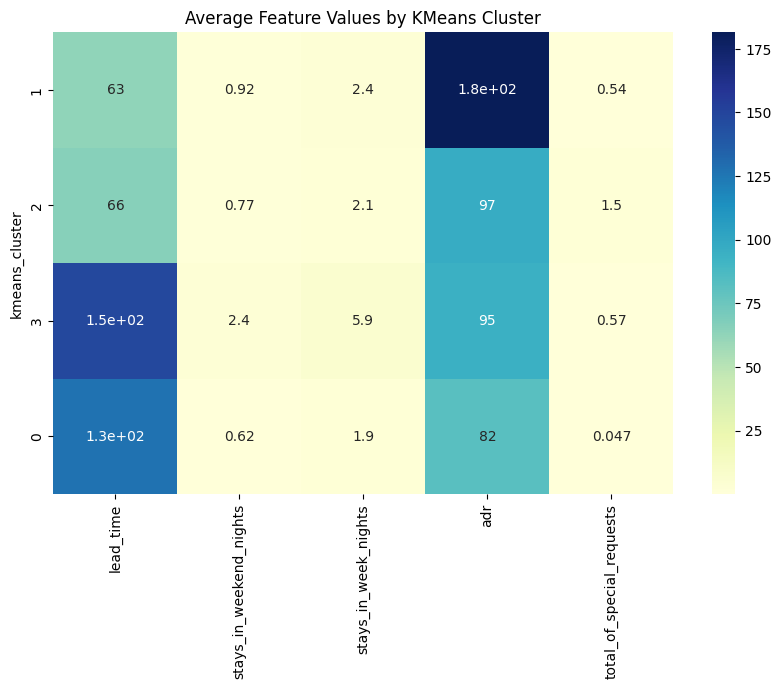

In [6]:
# Group by KMeans cluster and calculate average values
cluster_summary = cluster_df.groupby('kmeans_cluster')[features].mean().sort_values(by='adr', ascending=False)

print(cluster_summary)

# Optional heatmap for easier comparison
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu')
plt.title('Average Feature Values by KMeans Cluster')
plt.show()

### ✍️ Your Response: 🔧
The segments appear to represent different guest behaviors such as higher spending guests, longer stay guests, early planners, and lower request guests. A hotel could tailor promotions by offering premium packages to high adr guests, last minute deals to short lead time guests, and family or longer stay discounts to guests with longer visits.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
The most challenging part of unsupervised learning is that there is no single correct answer, so interpreting the clusters takes judgment. I would use clustering when there are no labels available and the goal is to discover patterns or customer groups. I would explain clustering to a non technical manager as a way to group similar customers so the business can target services, promotions, and pricing more effectively. This relates to my learning outcome because it helped me apply data analysis tools to real business decisions and turn patterns in data into useful insights.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [7]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_09_clustering.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
